# VGG16 Model - brain tumors

# Connection with google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Import datasets and load training, validation and testing

In [ ]:
import os
from keras.utils import image_dataset_from_directory

# base paths for datasets
train_dir = '/content/drive/MyDrive/updated/Training'
test_dir  = '/content/drive/MyDrive/updated/Testing'

batch_size = 8 #36
image_size = (512, 512)
seed = 1

# create datasets
train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical',  # categorical because we have more than 2 classes
    shuffle = True,
    seed = seed,
    validation_split = 0.2,
    subset = 'training'
)

validation_dataset = image_dataset_from_directory(
    train_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical',
    shuffle = True,
    seed = seed,
    validation_split = 0.2,
    subset = 'validation'
)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=image_size,
    batch_size=batch_size,
    label_mode='categorical',
    shuffle = False
)

epochs = 50 #change the epochs

Found 5711 files belonging to 4 classes.
Using 4569 files for training.
Found 5711 files belonging to 4 classes.
Using 1142 files for validation.
Found 1311 files belonging to 4 classes.


# Inspect dataset batch shapes




In [ ]:
for data_batch, label_batch in train_dataset:
    print('data batch shape ', data_batch.shape)
    print('label batch shape ', label_batch.shape)
    print('sample data shape ', data_batch[0].shape)
    print('sample labels ', label_batch[:5].numpy()) #show the first 5 labels

    break

data batch shape  (8, 512, 512, 3)
label batch shape  (8, 4)
sample data shape  (512, 512, 3)
sample labels  [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]


# Visualize sample MRI images and lables

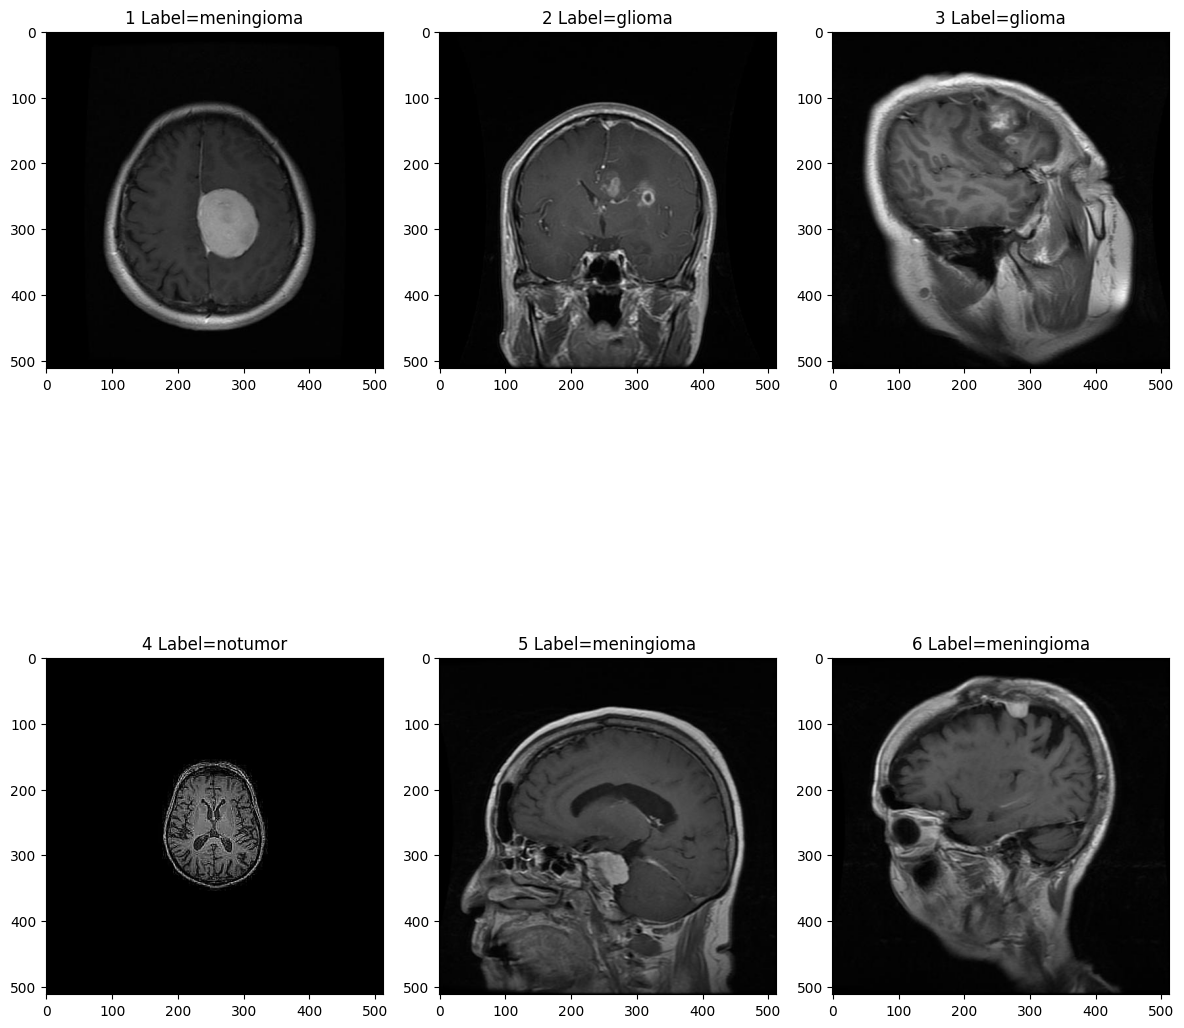

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = train_dataset.class_names

fig=plt.figure(figsize=(12,15))
columns = 3
rows = 2

for i in range(1, 7):
    img = data_batch[i]/255
    ax =fig.add_subplot(rows, columns, i)

    lbl_index = np.argmax(label_batch[i])
    lbl_name = class_names[lbl_index]

    fig.tight_layout()
    ax.title.set_text(str(i)+ " Label=" + lbl_name)
    plt.imshow(img)
plt.show()

# Building the VGG16 model

In [ ]:
import keras
from keras import models, layers, regularizers
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input

vgg_base = VGG16(weights='imagenet', include_top=False,input_shape=(512,512,3))
vgg_base.trainable = False

network = models.Sequential()
network.add(layers.Input(shape=(512,512,3)))

network.add(layers.RandomFlip("horizontal"))
network.add(layers.RandomRotation(0.05))
network.add(layers.RandomZoom(0.05))
#network.add(layers.RandomContrast(0.05))

network.add(layers.Lambda(preprocess_input))

network.add(vgg_base)
network.add(layers.GlobalAveragePooling2D())

network.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0001)))
network.add(layers.Dropout(0.3))

network.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0001)))
network.add(layers.Dropout(0.5))

network.add(layers.Dense(4, activation='softmax'))

network.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 512, 512, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 16, 16, 512)    │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,109,700 (57.64 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

# Callbacks and fine-tuning with training the model

In [ ]:
#from tensorflow.keras import optimizers
from keras import callbacks
from keras.optimizers import Adam

callbacks_phase2 = [
    callbacks.ModelCheckpoint(
        filepath="/content/drive/MyDrive/vgg_phase2_best.keras",
        save_best_only=True,
        monitor="val_loss",
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True
    ),
]

#for layer in vgg_base.layers:
    #layer.trainable = False

#for layer in vgg_base.layers[-4:]:
    #layer.trainable = True

vgg_base.trainable = True

for layer in vgg_base.layers[:-15]:
    layer.trainable = False

for layer in vgg_base.layers[-15:]:
    layer.trainable = True

print("Trainable VGG layers:", sum(l.trainable for l in vgg_base.layers), "/", len(vgg_base.layers))
print("Last 12 layers trainable status:")
for l in vgg_base.layers[-12:]:
    print(l.name, l.trainable)


network.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate = 0.00001), metrics=['acc'])

history_phase2 = network.fit(
    train_dataset,
    epochs=epochs,
    validation_data=validation_dataset,
    callbacks=callbacks_phase2
)

# -----------------------------
# saving the model
# -----------------------------
print("saving model")
network.save("/content/drive/MyDrive/vgg_phase2_clean.keras")
print("Clean model saved successfully!")

Trainable VGG layers: 15 / 19
Last 12 layers trainable status:
block3_conv1 True
block3_conv2 True
block3_conv3 True
block3_pool True
block4_conv1 True
block4_conv2 True
block4_conv3 True
block4_pool True
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True
Epoch 1/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 0s 598ms/step - acc: 0.5579 - loss: 1.1671
Epoch 1: val_loss improved from None to 0.38098, saving model to /content/drive/MyDrive/vgg_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/vgg_phase2_best.keras
572/572 ━━━━━━━━━━━━━━━━━━━━ 407s 685ms/step - acc: 0.7056 - loss: 0.8425 - val_acc: 0.9054 - val_loss: 0.3810
Epoch 2/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - acc: 0.8459 - loss: 0.5171
Epoch 2: val_loss did not improve from 0.38098
572/572 ━━━━━━━━━━━━━━━━━━━━ 403s 705ms/step - acc: 0.8599 - loss: 0.4799 - val_acc: 0.8835 - val_loss: 0.3929
Epoch 3/50
572/572 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - acc: 0.8953 - loss: 0.3982
Epoch 3: val_los

In [ ]:
import matplotlib.pyplot as plt

acc = history_phase2.history['acc']
val_acc = history_phase2.history['val_acc']
loss = history_phase2.history['loss']
val_loss = history_phase2.history['val_loss']
epocs = range(1, len(acc)+1)

#Accuracy and Loss plots

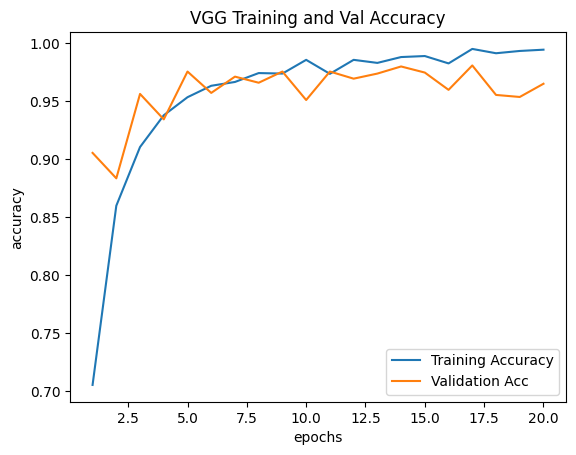

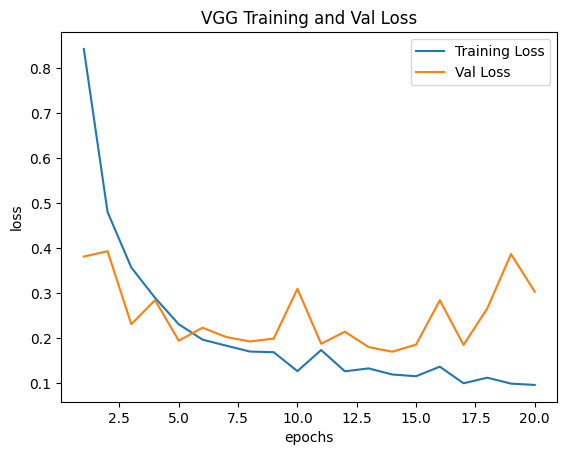

In [ ]:
plt.plot(epocs, acc, label='Training Accuracy')
plt.plot(epocs, val_acc, label='Validation Acc')
plt.legend()
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title('VGG Training and Val Accuracy')
plt.show()

plt.plot(epocs, loss, label='Training Loss')
plt.plot(epocs, val_loss, label='Val Loss')
plt.legend()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title('VGG Training and Val Loss')
plt.show()

# Load the best saved model and evaluate on testing data

In [ ]:
#from keras import models

#best_model = models.load_model(
#    "/content/drive/MyDrive/vgg_phase2_best.keras",
#    custom_objects={'preprocess_input': preprocess_input}
#)

#print("Phase 2 Test Accuracy:")
#print(best_model.evaluate(test_dataset))

from keras import models
from keras.applications.vgg16 import preprocess_input

best_model = models.load_model(
    "/content/drive/MyDrive/vgg_phase2_best.keras",
    custom_objects={'preprocess_input': preprocess_input}
)

print("Phase 2 Test Accuracy:")
print(best_model.evaluate(test_dataset))

# saving model
best_model.save("/content/drive/MyDrive/vgg_flask.keras")
print("Deployment model saved")

Phase 2 Test Accuracy:
164/164 ━━━━━━━━━━━━━━━━━━━━ 52s 310ms/step - acc: 0.9817 - loss: 0.1474
[0.14735405147075653, 0.9816933870315552]
Deployment model saved


# Check tensorflow and keras versions

In [ ]:
import tensorflow as tf
import keras
print("TF:", tf.__version__)
print("Keras:", keras.__version__)

TF: 2.19.0
Keras: 3.13.2


# Confusion Matrix

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
y_test: 1311 y_pred: 1311


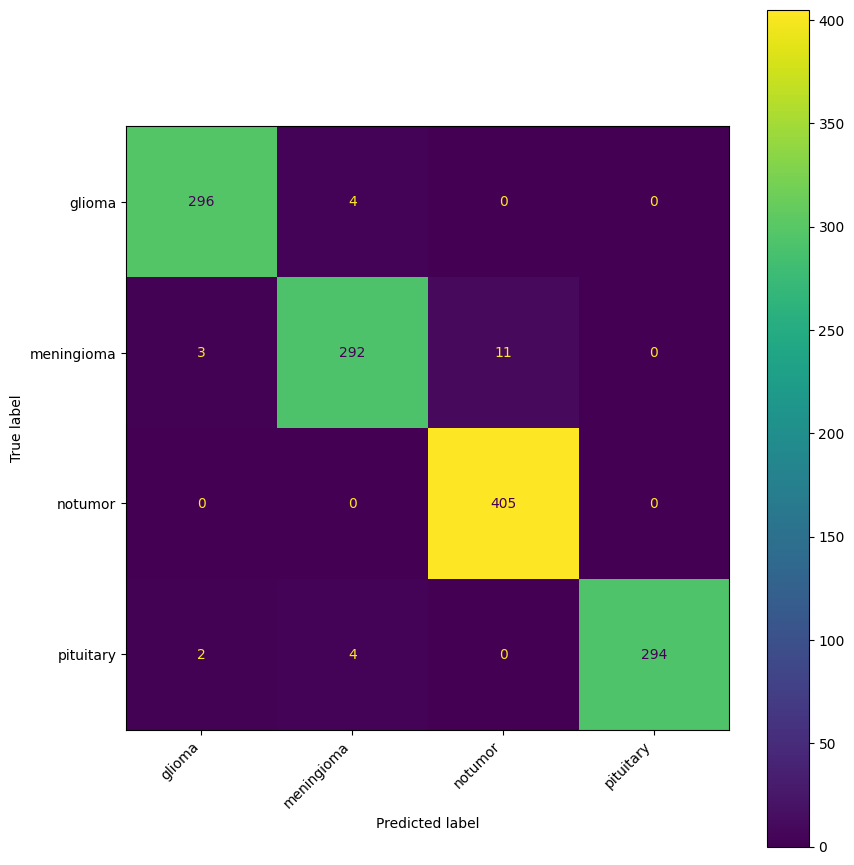

              precision    recall  f1-score   support

      glioma       0.98      0.99      0.99       300
  meningioma       0.97      0.95      0.96       306
     notumor       0.97      1.00      0.99       405
   pituitary       1.00      0.98      0.99       300

    accuracy                           0.98      1311
   macro avg       0.98      0.98      0.98      1311
weighted avg       0.98      0.98      0.98      1311



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from keras import models

def display_confusion_matrix(y_test, y_pred, labels):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    fig, ax = plt.subplots(figsize=(9, 9))
    disp.plot(ax=ax, values_format='d')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Load model
test_model = models.load_model(
    "/content/drive/MyDrive/vgg_phase2_best.keras",
    custom_objects={'preprocess_input': preprocess_input}
)

# Class names
labels = test_dataset.class_names
print("Class names:", labels)

# Ground truth
y_test = np.concatenate([
    np.argmax(y, axis=1)
    for _, y in test_dataset.as_numpy_iterator()
])

# Predictions
predicted = best_model.predict(test_dataset, verbose=0)
y_pred = np.argmax(predicted, axis=1)

print("y_test:", len(y_test), "y_pred:", len(y_pred))

# Metrics
display_confusion_matrix(y_test, y_pred, labels)
print(classification_report(y_test, y_pred, target_names=labels))
